### Библиотеки

In [17]:
import pandas as pd
import seaborn as sns
import scipy as scipy
import numpy as np

### Домашнее задание по лекции 8

Вы получили долгожданный оффер в Яндекс и пытаетесь улучшить время доставки еды. Вы внедрили улучшение на тестовой группе и теперь время сравнить результаты тестовой и контрольной группы.

Дан датасет:
 - id заказа
- время доставки
- район доставки
- флаг (контрольная или тестовая группа)

Необходимо, понять:
1) **Стоит ли раскатывать** улучшение на всех пользователей?
2) **Улучшился ли результат** в тестовой группе? Статистически **значим ли** он?

           order_id  delivery_time
count  20196.000000   20196.000000
mean   11103.503565      42.054169
std     5835.424404      10.382196
min     1000.000000      10.000000
25%     6048.750000      35.000000
50%    11109.500000      42.000000
75%    16158.250000      49.000000
max    21207.000000      83.000000
experiment_group
test       10104
control    10092
Name: count, dtype: int64
Стандартное отклонение контрольной группы 9.989522000653128 Среднее время контрольной группы 45.065101070154576
Стандартное отклонение тестовой группы 9.882819260031312 Среднее время поставок тестовой группы 39.04681314330958
Средее время доставки сокращено
Cтандартная ошибка среднего 0.0983182600434008
Доверительный интервал составил от 38.7931520323976 до 39.300474254221555
TtestResult(statistic=-43.03582663183714, pvalue=0.0, df=20194.0)


'pvalue меньше 0.05, что говорит о том, что две выборки не принадлежат одной ГС, поэтому гипотезу H0 отвергаем и принимаем во внимание гипотезу H1'

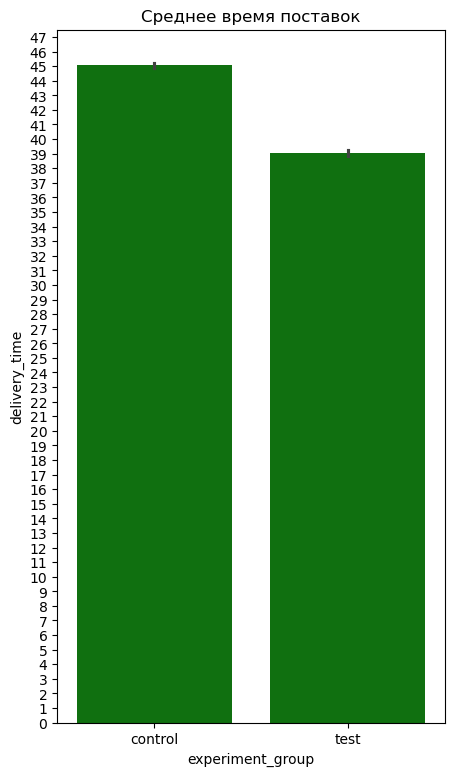

In [4]:
import pandas as pd
import scipy as scipy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Вариант 1
df = pd.read_csv(r'F:\Data science\Intensiv\октябрь 2025 ДЗ\Lection8.csv')
print(df.describe())
print(df['experiment_group'].value_counts())
df_control=df.query('experiment_group=="control"')
std_control = np. std(df_control['delivery_time'])
avr_del_time_control= df_control['delivery_time'].mean()
print(f"Стандартное отклонение контрольной группы {std_control}", f"Среднее время контрольной группы {avr_del_time_control}")
df_test=df.query('experiment_group=="test"')
std_test=np.std(df_test['delivery_time'])
avr_del_time_test = df_test['delivery_time'].mean()
print(f"Стандартное отклонение тестовой группы {std_test}", f"Среднее время поставок тестовой группы {avr_del_time_test}")
if avr_del_time_test<avr_del_time_control: 
    print("Средее время доставки сокращено")
elif avr_del_time_test>=avr_del_time:
     print("Средее время доставки увеличено или осталось без изменений")
plt.figure(figsize=(5,9))
plt.yticks(np.arange(50))
plt.title ('Среднее время поставок')
sns.barplot(data=df, x='experiment_group',y='delivery_time', color='green')
"""Формируем гипотезы: 
H0: Разницы между тестовой и контрольной группами нет. Улучшение времени доставки случайно.
H1: Изменение значимо, изменения для тестовой группы действительно улучшают время доставки"""
SE=std_test/(len(df_test)**0.5) #Cтандартная ошибка среднего
print(f"Cтандартная ошибка среднего {SE}")
d_1= avr_del_time_test-2.58*SE #левая граница
d_2=avr_del_time_test+2.58*SE #правая граница
print(f"Доверительный интервал составил от {d_1} до {d_2}")
""" Как видно, среднее время поставок{avr_del_time_control} не попало в доверительный интервал, поэтому принимаем гипотезу H1.
Итого, отвечая на вопросы:
1. Раскатываем улучшение на всех пользователей;
2. Средее время доставки в тестовой группе сокращено. Результат статистически значим. """
#Вариант 2
df = pd.read_csv(r'F:\Data science\Intensiv\октябрь 2025 ДЗ\Lection8.csv')
from scipy.stats import ttest_ind
""" Формируем гипотезы
H0: Разницы между тестовой и контрольной группами нет. Улучшение времени доставки для тестовой группы случайно.
H1: Изменение значимо, изменения для тестовой группы действительно улучшают время доставки"""
test=list(df.query('experiment_group=="test"').delivery_time)
control= list(df.query('experiment_group=="control"').delivery_time)
print(ttest_ind(test,control))
"""pvalue меньше 0.05, что говорит о том, что две выборки не принадлежат одной ГС, поэтому гипотезу H0 отвергаем и принимаем во внимание гипотезу H1"""